# Arabic Dialect Sentiment Analysis
## Three Dialects: Saudi 🇸🇦 | Egyptian 🇪🇬 | Jordanian 🇯🇴
### CamelBERT Multi-Task Fine-Tuning
---
**Pipeline:**
1. Mount Drive & Load Data
2. Pre-processing (normalize, negation tagging)
3. TF-IDF / Word2Vec / MARBERT feature extraction
4. Classical models (LR + SVM)
5. Multi-Task CamelBERT Fine-Tuning (Sentiment + Dialect)
6. Evaluation & Comparison
7. Gradio Interface

In [ ]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 96.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 69.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 92.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 62.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 134.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
!pip install -q --force-reinstall numpy==1.26.4 pandas==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 37.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you

In [ ]:
!pip install -q numpy==2.0.0 pandas==2.2.3 --break-system-packages


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 98.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [ ]:
import numpy as np
import pandas as pd
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

numpy: 2.0.2
pandas: 2.2.3


In [ ]:
!pip install -q \
  numpy==2.0.0 \
  pandas==2.2.3 \
  scipy \
  scikit-learn \
  transformers==4.44.2 \
  huggingface_hub==0.24.7 \
  tokenizers==0.19.1 \
  accelerate==0.34.2 \
  gradio==4.44.1 \
  gensim arabert pyarabic seaborn openpyxl \
  --break-system-packages

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 22.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 148.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.5/417.5 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 135.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 115.6 MB/s eta 0:00:00


In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
!pip install -q gensim arabert pyarabic --break-system-packages

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np, re, time, os, random, sys
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from gensim.models import Word2Vec

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Mounted at /content/drive
Device: cuda


In [ ]:
# تثبيت نسخ متوافقة — لا تستخدمي transformers --upgrade لأنه يسبب تضارب مع huggingface_hub/Gradio
!pip install -q transformers==4.44.2 huggingface_hub==0.24.7 tokenizers==0.19.1 accelerate==0.33.0 gradio==4.44.1 gensim arabert pyarabic scikit-learn seaborn openpyxl

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np, re, time, os, random, sys
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from gensim.models import Word2Vec

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 15.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
yfinance 0.2.66 requires websockets>=13.0, but you have websockets 12.0 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have n

In [ ]:
BASE_PATH = '/content/drive/MyDrive/sentiment_data/'

import sys, os
sys.path.append(BASE_PATH)

# قراءة الداتا
df_eg = pd.read_excel(BASE_PATH + 'Eygaptian_dataset_version2.xlsx')
df_jo = pd.read_excel(BASE_PATH + 'Jordan_dataset_version2.xlsx')
df_sa = pd.read_excel(BASE_PATH + 'saudi_youtube_comments.xlsx')

# توحيد الأعمدة
df_eg = df_eg[['النص','التصنيف']].rename(columns={'النص':'text','التصنيف':'sentiment'})
df_jo = df_jo[['comment','sentiment']].rename(columns={'comment':'text','sentiment':'sentiment'})
df_sa = df_sa[['النص','التصنيف']].rename(columns={'النص':'text','التصنيف':'sentiment'})

# إضافة اللهجات
df_eg['dialect'] = 'Egyptian'
df_jo['dialect'] = 'Jordanian'
df_sa['dialect'] = 'Saudi'

# دمج
df = pd.concat([df_eg, df_jo, df_sa], ignore_index=True)

# تنظيف الليبل
sentiment_map = {
    'Positive ': 'إيجابي', 'Positive': 'إيجابي', 'positive': 'إيجابي', 'pos': 'إيجابي', 'ايجابي': 'إيجابي', 'إيجابي': 'إيجابي',
    'Negative ': 'سلبي',  'Negative': 'سلبي',  'negative': 'سلبي',  'neg': 'سلبي',  'سلبي': 'سلبي',
    'Neutral ':  'محايد',  'Neutral':  'محايد',  'neutral':  'محايد',  'neu': 'محايد',  'محايد': 'محايد',
}

df['sentiment'] = df['sentiment'].astype(str).str.strip().replace(sentiment_map)
df['text']      = df['text'].astype(str).str.strip()

# فلترة
df = df[df['sentiment'].isin(['سلبي','محايد','إيجابي'])].copy()
df = df[df['text'].str.len() > 0].reset_index(drop=True)

# طباعة النتائج
print(f"Total dataset size: {len(df):,}")

print("\nDialect distribution:")
print(df["dialect"].value_counts())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nCross-tab:")
print(pd.crosstab(df['dialect'], df['sentiment']))

print("\nFiles in BASE_PATH:")
print(os.listdir(BASE_PATH))

Total dataset size: 30,591

Dialect distribution:
dialect
Saudi        12980
Egyptian      9995
Jordanian     7616
Name: count, dtype: int64

Sentiment distribution:
sentiment
إيجابي    12554
محايد     11183
سلبي       6854
Name: count, dtype: int64

Cross-tab:
sentiment  إيجابي  سلبي  محايد
dialect                       
Egyptian     5135  4548    312
Jordanian    3027   900   3689
Saudi        4392  1406   7182

Files in BASE_PATH:
['jordan_full_dataset.xlsx', 'egyptian_full_dataset.xlsx', 'Saudi_full_dataset.xlsx', 'camelbert_multitask.pt', 'Eygaptian_dataset_version2.xlsx', 'Jordan_dataset_version2.xlsx', 'saudi_youtube_comments.xlsx', 'collecting_data_from_youtube_سعودي.ipynb', 'collecting_data_from_youtube_EG.ipynb', 'collecting_data_from_youtube_jord.ipynb', 'X_test_bert.npy', 'X_train_bert.npy', 'X_test_dialect_bert.npy', 'X_train_dialect_bert.npy', 'marbert_multitask_best.pt', 'sentiment_data']


In [ ]:
import os

# List all files in the BASE_PATH directory
try:
    files = os.listdir(BASE_PATH)
    print(f"Files in '{BASE_PATH}':")
    for f in files:
        print(f)
except FileNotFoundError:
    print(f"Error: The directory '{BASE_PATH}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Files in '/content/drive/MyDrive/sentiment_data/':
jordan_full_dataset.xlsx
egyptian_full_dataset.xlsx
Saudi_full_dataset.xlsx
camelbert_multitask.pt
Eygaptian_dataset_version2.xlsx
Jordan_dataset_version2.xlsx
saudi_youtube_comments.xlsx
collecting_data_from_youtube_سعودي.ipynb
collecting_data_from_youtube_EG.ipynb
collecting_data_from_youtube_jord.ipynb
X_test_bert.npy
X_train_bert.npy
X_test_dialect_bert.npy
X_train_dialect_bert.npy
marbert_multitask_best.pt
sentiment_data


In [ ]:
import os
for f in os.listdir(BASE_PATH):
    if 'dict' in f.lower() or 'norm' in f.lower():
        print(f)

In [ ]:
import os

# تحقق إذا الملفات موجودة في sentiment_data
for f in os.listdir(BASE_PATH):
    print(f)

jordan_full_dataset.xlsx
egyptian_full_dataset.xlsx
Saudi_full_dataset.xlsx
camelbert_multitask.pt
Eygaptian_dataset_version2.xlsx
Jordan_dataset_version2.xlsx
saudi_youtube_comments.xlsx
collecting_data_from_youtube_سعودي.ipynb
collecting_data_from_youtube_EG.ipynb
collecting_data_from_youtube_jord.ipynb
X_test_bert.npy
X_train_bert.npy
X_test_dialect_bert.npy
X_train_dialect_bert.npy
marbert_multitask_best.pt
sentiment_data


In [ ]:
# ✅ Preprocessing  Gender normalization + Verb root normalization

import re
import numpy as np

# ===== القواميس مدمجة مباشرة =====
verb_root_normalization_dict = {
    'اعيط': 'عيط', 'أعيط': 'عيط', 'بعيط': 'عيط', 'باعيط': 'عيط', 'هعيط': 'عيط',
    'عيطت': 'عيط', 'عيطتلك': 'عيط', 'عيطتلها': 'عيط', 'عيطنا': 'عيط', 'عيطوا': 'عيط',
    'يعيط': 'عيط', 'تعيط': 'عيط', 'هتعيط': 'عيط', 'هتعيطو': 'عيط',
    'اصيح': 'صيح', 'بصيح': 'صيح', 'صحت': 'صيح',
    'مروق': 'روق', 'رايق': 'روق',
    'مستانس': 'ونس', 'مستانسه': 'ونس', 'مستانسة': 'ونس',
    'معصب': 'عصب', 'معصبه': 'عصب', 'معصبة': 'عصب',
    'مبسوط': 'بسط', 'مبسوطه': 'بسط', 'مبسوطة': 'بسط',
    'طفشان': 'طفش', 'طفشانه': 'طفش', 'طفشانة': 'طفش',
    'مضغوط': 'ضغط', 'مضغوطه': 'ضغط', 'مضغوطة': 'ضغط',
    'مقهور': 'قهر', 'مقهوره': 'قهر', 'مقهورة': 'قهر',
}

gender_normalization_dict = {
    'مستانسه': 'مستانس', 'مستانسة': 'مستانس',
    'مبسوطه': 'مبسوط', 'مبسوطة': 'مبسوط',
    'معصبه': 'معصب', 'معصبة': 'معصب',
    'تعبانه': 'تعبان', 'تعبانة': 'تعبان',
    'خايسه': 'خايس', 'خايسة': 'خايس',
    'مضغوطه': 'مضغوط', 'مضغوطة': 'مضغوط',
    'مقهوره': 'مقهور', 'مقهورة': 'مقهور',
    'طفشانه': 'طفشان', 'طفشانة': 'طفشان',
}

NEGATION_MARKERS = [
    r'\bمو\b', r'\bما\b', r'\bبدون\b', r'\bلا\b', r'\bمب\b',
    r'\bمش\b', r'\bمفيش\b', r'\bمافي\b', r'\bليس\b', r'\bلم\b', r'\bلن\b',
]
NEGATION_PATTERN = re.compile('|'.join(NEGATION_MARKERS))

def remove_diacritics(text):
    return re.sub(r'[\u064b-\u065f\u0670]', '', str(text))

def normalize_arabic_light(text):
    text = str(text)
    text = remove_diacritics(text)
    text = re.sub(r'[إأآٱ]', 'ا', text)
    text = text.replace('ى', 'ي')
    text = text.replace('ؤ', 'و').replace('ئ', 'ي')
    text = re.sub(r'(.)\1+', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_gender_auto(word):
    w = normalize_arabic_light(word)
    if w in gender_normalization_dict:
        return gender_normalization_dict[w]
    if len(w) > 3 and (w.endswith('ه') or w.endswith('ة')):
        return w[:-1]
    return w

def normalize_tokens(text):
    words = str(text).split()
    out = []
    for w in words:
        w1 = normalize_gender_auto(w)
        w2 = verb_root_normalization_dict.get(w1, w1)
        out.append(w2)
    return ' '.join(out)

def split_negation(text):  # ✅ بدون مسافة في البداية
    text = re.sub(r'^(ما|مو|مش|مب|مافي|مفيش)([\u0621-\u064A]{2,})', r'\1 \2', text)
    text = re.sub(r'\s(ما|مو|مش|مب|مافي|مفيش)([\u0621-\u064A]{2,})', r' \1 \2', text)
    return text

def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)
    text = re.sub(r'#', ' ', text)
    text = re.sub(r'[0-9٠-٩]+', ' NUM ', text)
    text = normalize_arabic_light(text)
    text = re.sub(r'[^\u0621-\u063A\u0641-\u064A\sA-Za-z_]', ' ', text)
    text = normalize_tokens(text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def bert_preprocess(text):  # ✅ مرة وحدة فقط
    text = str(text)
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)
    text = re.sub(r'#', ' ', text)
    text = normalize_arabic_light(text)
    text = normalize_tokens(text)
    text = split_negation(text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def add_negation_tags(text):
    words = text.split()
    result = []
    negate_next = False
    for word in words:
        if re.match(r'^مافي', word) or (word.endswith('ش') and len(word) > 3):
            result.append(word + '_NEG')
            negate_next = False
        elif NEGATION_PATTERN.fullmatch(word):
            result.append(word)
            negate_next = True
        elif negate_next:
            result.append(word + '_NEG')
            negate_next = False
        else:
            result.append(word)
    return ' '.join(result)

def full_preprocess(text):
    return add_negation_tags(clean_text(text))

# ===== تطبيق على الداتا =====
df['processed_text'] = df['text'].apply(full_preprocess)
df['bert_text']      = df['text'].apply(bert_preprocess)

df['processed_text'] = df['processed_text'].replace('', np.nan)
df['bert_text']      = df['bert_text'].replace('', np.nan)
df = df.dropna(subset=['processed_text', 'bert_text']).reset_index(drop=True)

print('✅ تم تطبيق المعالجة')
print('حجم قاموس الجذور:', len(verb_root_normalization_dict))
print('حجم قاموس الجندر:', len(gender_normalization_dict))

print('\nاختبار سريع:')
for sample in [
    'مبسوطة مرة', 'مبسوطه مره', 'معصبة جدا',
    'مضغوطة اليوم', 'مقهورة مره', 'عيطت كتير مبارح',
    'وع الاكل خايس', 'اليوم انا مرتفع ضغطي ومعصبة',
    'ماعجبني', 'موكويس', 'مشحلو',
]:
    print(sample, '=>', bert_preprocess(sample))

print(f'\nحجم الداتا بعد التنظيف: {len(df):,}')

✅ تم تطبيق المعالجة
حجم قاموس الجذور: 37
حجم قاموس الجندر: 16

اختبار سريع:
مبسوطة مرة => بسط مرة
مبسوطه مره => بسط مره
معصبة جدا => عصب جدا
مضغوطة اليوم => ضغط اليوم
مقهورة مره => قهر مره
عيطت كتير مبارح => عيط كتير مب ارح
وع الاكل خايس => وع الاكل خايس
اليوم انا مرتفع ضغطي ومعصبة => اليوم انا مرتفع ضغطي ومعصب
ماعجبني => ما عجبني
موكويس => مو كويس
مشحلو => مش حلو

حجم الداتا بعد التنظيف: 30,591


In [ ]:

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

df['dialect_sentiment'] = df['dialect'] + '_' + df['sentiment']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['processed_text'], df['label'],
    test_size=0.2, random_state=SEED, stratify=df['dialect_sentiment']
)

# نسخة camelBERT تستخدم النص الخفيف بدون _NEG ✅
X_train_bert_text = df.loc[X_train_raw.index, 'bert_text']
X_test_bert_text  = df.loc[X_test_raw.index,  'bert_text']

print(f'Train: {len(X_train_raw):,} | Test: {len(X_test_raw):,}')
print('\nتوزيع اللهجات في Test:')
print(df.loc[X_test_raw.index, 'dialect'].value_counts())

Label mapping: {'إيجابي': np.int64(0), 'سلبي': np.int64(1), 'محايد': np.int64(2)}
Train: 24,472 | Test: 6,119

توزيع اللهجات في Test:
dialect
Saudi        2597
Egyptian     1999
Jordanian    1523
Name: count, dtype: int64


In [ ]:
tfidf = TfidfVectorizer(analyzer='char_wb', max_features=50000, ngram_range=(2,4), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)
print('TF-IDF train:', X_train_tfidf.shape)
print('TF-IDF test: ', X_test_tfidf.shape)

TF-IDF train: (24472, 50000)
TF-IDF test:  (6119, 50000)


In [ ]:
train_tokens = [t.split() for t in X_train_raw]
test_tokens  = [t.split() for t in X_test_raw]

w2v = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=2, sg=1, epochs=10, seed=42)
print('Word2Vec vocab:', len(w2v.wv))

def sentence_vector(tokens, model, size=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X_train_w2v = np.array([sentence_vector(t, w2v) for t in train_tokens])
X_test_w2v  = np.array([sentence_vector(t, w2v) for t in test_tokens])
print('Word2Vec train:', X_train_w2v.shape)

Word2Vec vocab: 21494
Word2Vec train: (24472, 100)


In [ ]:
import transformers, huggingface_hub
print('transformers:', transformers.__version__)
print('huggingface_hub:', huggingface_hub.__version__)

transformers: 4.44.2
huggingface_hub: 0.24.7


In [ ]:
!pip install -q sentencepiece --break-system-packages


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np, re, time, os, random, sys
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from gensim.models import Word2Vec

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
MODEL_NAME = 'CAMeL-Lab/bert-base-arabic-camelbert-mix'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
camelbert_model = AutoModel.from_pretrained(MODEL_NAME).to(device)  # ✅ غيّرنا الاسم
camelbert_model.eval()
print(f'✅ تم تحميل {MODEL_NAME}')

# دالة استخراج الـ embeddings
@torch.no_grad()
def get_camelbert_embeddings(texts, batch_size=64, max_length=160):  # ✅ غيّرنا اسم الدالة
    all_emb = []
    texts = list(texts)
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}
        out = camelbert_model(**enc)  # ✅ غيّرنا الاسم
        all_emb.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        if (i // batch_size + 1) % 10 == 0:
            print(f'  {min(i+batch_size, len(texts)):,}/{len(texts):,}')
    return np.vstack(all_emb)

# استخراج الـ embeddings
print('\nاستخراج embeddings...')
X_train_bert = get_camelbert_embeddings(X_train_bert_text)  # ✅
X_test_bert  = get_camelbert_embeddings(X_test_bert_text)   # ✅
print(f'Train: {X_train_bert.shape} | Test: {X_test_bert.shape}')

# نسخة dialect prefix
prefix_map = {'Saudi':'[SAU]', 'Egyptian':'[EGY]', 'Jordanian':'[JOR]', 'Lebanese':'[LEB]'}
X_train_dialect_bert = get_camelbert_embeddings(  # ✅
    df.loc[X_train_raw.index, 'dialect'].map(prefix_map).fillna('[DIA]') + ' ' + X_train_bert_text
)
X_test_dialect_bert = get_camelbert_embeddings(   # ✅
    df.loc[X_test_raw.index, 'dialect'].map(prefix_map).fillna('[DIA]') + ' ' + X_test_bert_text
)

# حفظ في Drive
np.save(BASE_PATH + 'X_train_bert.npy',         X_train_bert)
np.save(BASE_PATH + 'X_test_bert.npy',          X_test_bert)
np.save(BASE_PATH + 'X_train_dialect_bert.npy', X_train_dialect_bert)
np.save(BASE_PATH + 'X_test_dialect_bert.npy',  X_test_dialect_bert)
print('✅ تم الحفظ في Drive')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

✅ تم تحميل CAMeL-Lab/bert-base-arabic-camelbert-mix

استخراج embeddings...
  640/24,472
  1,280/24,472
  1,920/24,472
  2,560/24,472
  3,200/24,472
  3,840/24,472
  4,480/24,472
  5,120/24,472
  5,760/24,472
  6,400/24,472
  7,040/24,472
  7,680/24,472
  8,320/24,472
  8,960/24,472
  9,600/24,472
  10,240/24,472
  10,880/24,472
  11,520/24,472
  12,160/24,472
  12,800/24,472
  13,440/24,472
  14,080/24,472
  14,720/24,472
  15,360/24,472
  16,000/24,472
  16,640/24,472
  17,280/24,472
  17,920/24,472
  18,560/24,472
  19,200/24,472
  19,840/24,472
  20,480/24,472
  21,120/24,472
  21,760/24,472
  22,400/24,472
  23,040/24,472
  23,680/24,472
  24,320/24,472
  640/6,119
  1,280/6,119
  1,920/6,119
  2,560/6,119
  3,200/6,119
  3,840/6,119
  4,480/6,119
  5,120/6,119
  5,760/6,119
Train: (24472, 768) | Test: (6119, 768)
  640/24,472
  1,280/24,472
  1,920/24,472
  2,560/24,472
  3,200/24,472
  3,840/24,472
  4,480/24,472
  5,120/24,472
  5,760/24,472
  6,400/24,472
  7,040/24,472
  7,680

In [ ]:

def train_eval(model, X_tr, X_te, y_tr, y_te, mname, fname):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    macro = f1_score(y_te, y_pred, average='macro')
    print('='*60)
    print(f'Model: {mname} | Features: {fname}')
    print(f'Accuracy: {acc:.4f} | Macro-F1: {macro:.4f}')
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    return acc

acc_tfidf_lr  = train_eval(LogisticRegression(max_iter=2000, class_weight='balanced'), X_train_tfidf, X_test_tfidf, y_train, y_test, 'LR',  'TF-IDF')
acc_tfidf_svm = train_eval(LinearSVC(C=1.0, max_iter=5000, class_weight='balanced'),  X_train_tfidf, X_test_tfidf, y_train, y_test, 'SVM', 'TF-IDF')
acc_w2v_lr    = train_eval(LogisticRegression(max_iter=2000, class_weight='balanced'), X_train_w2v,   X_test_w2v,   y_train, y_test, 'LR',  'Word2Vec')
acc_w2v_svm   = train_eval(LinearSVC(C=1.0, max_iter=5000, class_weight='balanced'),  X_train_w2v,   X_test_w2v,   y_train, y_test, 'SVM', 'Word2Vec')
acc_bert_lr   = train_eval(LogisticRegression(max_iter=2000, class_weight='balanced'), X_train_bert,  X_test_bert,  y_train, y_test, 'LR',  'camelBERT')  # ✅
acc_bert_svm  = train_eval(LinearSVC(C=1.0, max_iter=5000, class_weight='balanced'),  X_train_bert,  X_test_bert,  y_train, y_test, 'SVM', 'camelBERT')  # ✅

Model: LR | Features: TF-IDF
Accuracy: 0.7722 | Macro-F1: 0.7661
              precision    recall  f1-score   support

      إيجابي       0.85      0.73      0.78      2511
        سلبي       0.74      0.72      0.73      1371
       محايد       0.72      0.85      0.78      2237

    accuracy                           0.77      6119
   macro avg       0.77      0.77      0.77      6119
weighted avg       0.78      0.77      0.77      6119

Model: SVM | Features: TF-IDF
Accuracy: 0.7725 | Macro-F1: 0.7659
              precision    recall  f1-score   support

      إيجابي       0.83      0.76      0.79      2511
        سلبي       0.75      0.70      0.73      1371
       محايد       0.73      0.83      0.78      2237

    accuracy                           0.77      6119
   macro avg       0.77      0.76      0.77      6119
weighted avg       0.78      0.77      0.77      6119

Model: LR | Features: Word2Vec
Accuracy: 0.6784 | Macro-F1: 0.6736
              precision    recall  f1-sc

,Feature,Model,Accuracy
0,TF-IDF,SVM,0.772512
1,TF-IDF,LR,0.772185
2,camelBERT,SVM,0.723811
3,camelBERT,LR,0.717928
4,Word2Vec,SVM,0.689165
5,Word2Vec,LR,0.678379


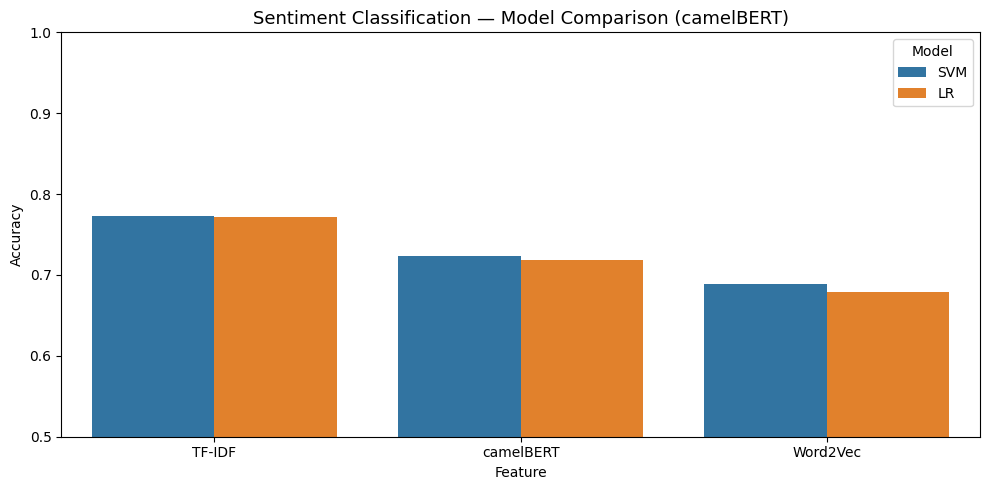

In [ ]:
results = pd.DataFrame({
    'Feature': ['TF-IDF','TF-IDF','Word2Vec','Word2Vec','camelBERT','camelBERT'],  # ✅
    'Model':   ['LR','SVM','LR','SVM','LR','SVM'],
    'Accuracy':[acc_tfidf_lr, acc_tfidf_svm, acc_w2v_lr, acc_w2v_svm, acc_bert_lr, acc_bert_svm]
})
results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
display(results)

plt.figure(figsize=(10,5))
sns.barplot(data=results, x='Feature', y='Accuracy', hue='Model')
plt.title('Sentiment Classification — Model Comparison (camelBERT)', fontsize=13)  # ✅
plt.ylim(0.5, 1); plt.tight_layout(); plt.show()

## 🚀 Multi-Task CamelBERT Fine-Tuning
### يتعلم المشاعر واللهجة في نفس الوقت

In [ ]:

le_sent = LabelEncoder()
le_dial = LabelEncoder()
df['label_s'] = le_sent.fit_transform(df['sentiment'])
df['label_d'] = le_dial.fit_transform(df['dialect'])

print('Sentiment mapping:', dict(zip(le_sent.classes_, le_sent.transform(le_sent.classes_))))
print('Dialect mapping:  ', dict(zip(le_dial.classes_, le_dial.transform(le_dial.classes_))))

NUM_SENT = len(le_sent.classes_)
NUM_DIAL = len(le_dial.classes_)
assert NUM_SENT == 3, f'المشاعر لازم تكون 3، الموجود: {NUM_SENT} -> {list(le_sent.classes_)}'
assert NUM_DIAL == 3, f'اللهجات لازم تكون 3، الموجود: {NUM_DIAL} -> {list(le_dial.classes_)}'

df['ds'] = df['dialect'] + '_' + df['sentiment']
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['ds'])
train_df, val_df  = train_test_split(train_df, test_size=0.1, random_state=SEED, stratify=train_df['ds'])
print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print('\nTrain cross-tab:')
print(pd.crosstab(train_df['dialect'], train_df['sentiment']))


Sentiment mapping: {'إيجابي': np.int64(0), 'سلبي': np.int64(1), 'محايد': np.int64(2)}
Dialect mapping:   {'Egyptian': np.int64(0), 'Jordanian': np.int64(1), 'Saudi': np.int64(2)}
Train: 22,024 | Val: 2,448 | Test: 6,119

Train cross-tab:
sentiment  إيجابي  سلبي  محايد
dialect                       
Egyptian     3697  3274    225
Jordanian    2180   648   2656
Saudi        3162  1012   5170


In [ ]:

BATCH_SIZE = 16 if torch.cuda.is_available() else 8
MAX_LEN    = 160

class ArabicDataset(Dataset):
    def __init__(self, texts, s_labels, d_labels, tokenizer, max_len):
        self.texts    = list(texts)
        self.s_labels = list(s_labels)
        self.d_labels = list(d_labels)
        self.tok      = tokenizer
        self.max_len  = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], padding='max_length', truncation=True,
                       max_length=self.max_len, return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'sentiment_label':torch.tensor(self.s_labels[idx], dtype=torch.long),
            'dialect_label':  torch.tensor(self.d_labels[idx], dtype=torch.long),
        }

tokenizer_ft = AutoTokenizer.from_pretrained(MODEL_NAME)

# مهم: Fine-tuning يستخدم bert_text الخفيف، وليس processed_text الذي يحتوي _NEG
train_ds = ArabicDataset(train_df['bert_text'], train_df['label_s'], train_df['label_d'], tokenizer_ft, MAX_LEN)
val_ds   = ArabicDataset(val_df['bert_text'],   val_df['label_s'],   val_df['label_d'],   tokenizer_ft, MAX_LEN)
test_ds  = ArabicDataset(test_df['bert_text'],  test_df['label_s'],  test_df['label_d'],  tokenizer_ft, MAX_LEN)

# Sampler يوازن المشاعر واللهجة معاً حتى لا يطغى كلاس على الثاني
combo_counts = train_df['ds'].value_counts().to_dict()
sample_weights = train_df['ds'].map(lambda x: 1.0 / combo_counts[x]).values
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Batches → Train:{len(train_loader)} | Val:{len(val_loader)} | Test:{len(test_loader)} | MAX_LEN:{MAX_LEN} | BATCH:{BATCH_SIZE}')


Batches → Train:1377 | Val:153 | Test:383 | MAX_LEN:160 | BATCH:16


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
import torch
from transformers import AutoModel

MODEL_NAME = 'CAMeL-Lab/bert-base-arabic-camelbert-mix'
bert_base = AutoModel.from_pretrained(MODEL_NAME)
print('✅ تم تحميل camelBERT weights')  # ✅

class MultiTaskCamelBERT(nn.Module):
    def __init__(self, bert_model, num_sent, num_dial, dropout=0.25):
        super().__init__()
        self.bert = bert_model
        hidden = self.bert.config.hidden_size

        self.shared = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )

        self.sentiment_head = nn.Sequential(
            nn.Linear(hidden, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_sent)
        )
        self.dialect_head = nn.Sequential(
            nn.Linear(hidden, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_dial)
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        z = self.shared(cls)
        return self.sentiment_head(z), self.dialect_head(z)

model_ft = MultiTaskCamelBERT(bert_base, NUM_SENT, NUM_DIAL, dropout=0.25).to(device)
print(f'Parameters: {sum(p.numel() for p in model_ft.parameters()):,}')

✅ تم تحميل camelBERT weights
Parameters: 110,068,742


In [ ]:
# ====== Imports الخاصة بالتدريب ======

import torch
import torch.nn as nn

from transformers import AdamW, get_linear_schedule_with_warmup

from sklearn.utils.class_weight import compute_class_weight

In [ ]:

EPOCHS         = 8
LR             = 1e-5
SENT_WEIGHT    = 0.85   # المشاعر هي الهدف الأساسي
DIAL_WEIGHT    = 0.15   # اللهجة تساعد فقط وما تخرب تصنيف المشاعر
PATIENCE       = 2

no_decay = ['bias', 'LayerNorm.weight']
params = [
    {'params': [p for n,p in model_ft.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n,p in model_ft.named_parameters() if     any(nd in n for nd in no_decay)], 'weight_decay': 0.0},
]
optimizer    = AdamW(params, lr=LR)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.10)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# Class weights للمشاعر واللهجة
sent_weights = compute_class_weight('balanced', classes=np.arange(NUM_SENT), y=train_df['label_s'].values)
dial_weights = compute_class_weight('balanced', classes=np.arange(NUM_DIAL), y=train_df['label_d'].values)
criterion_s  = nn.CrossEntropyLoss(weight=torch.tensor(sent_weights, dtype=torch.float).to(device), label_smoothing=0.03)
criterion_d  = nn.CrossEntropyLoss(weight=torch.tensor(dial_weights, dtype=torch.float).to(device), label_smoothing=0.03)

print(f'Total steps: {total_steps} | Warmup: {warmup_steps}')
print('Sentiment weights:', dict(zip(le_sent.classes_, np.round(sent_weights, 3))))
print('Dialect weights:  ', dict(zip(le_dial.classes_, np.round(dial_weights, 3))))


Total steps: 11016 | Warmup: 1101
Sentiment weights: {'إيجابي': np.float64(0.812), 'سلبي': np.float64(1.488), 'محايد': np.float64(0.912)}
Dialect weights:   {'Egyptian': np.float64(1.02), 'Jordanian': np.float64(1.339), 'Saudi': np.float64(0.786)}


/usr/local/lib/python3.12/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:

def _metrics(y_true, y_pred):
    return {
        'acc': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted')
    }

def train_one_epoch(model, loader):
    model.train()
    total_loss, sp, dp, st, dt = 0, [], [], [], []
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        sl   = batch['sentiment_label'].to(device)
        dl   = batch['dialect_label'].to(device)
        optimizer.zero_grad(set_to_none=True)
        s_log, d_log = model(ids, mask)
        loss = SENT_WEIGHT * criterion_s(s_log, sl) + DIAL_WEIGHT * criterion_d(d_log, dl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
        sp.extend(s_log.argmax(1).detach().cpu().numpy()); st.extend(sl.detach().cpu().numpy())
        dp.extend(d_log.argmax(1).detach().cpu().numpy()); dt.extend(dl.detach().cpu().numpy())
    sm, dm = _metrics(st, sp), _metrics(dt, dp)
    return total_loss/len(loader), sm, dm

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, sp, dp, st, dt = 0, [], [], [], []
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        sl   = batch['sentiment_label'].to(device)
        dl   = batch['dialect_label'].to(device)
        s_log, d_log = model(ids, mask)
        loss = SENT_WEIGHT * criterion_s(s_log, sl) + DIAL_WEIGHT * criterion_d(d_log, dl)
        total_loss += loss.item()
        sp.extend(s_log.argmax(1).cpu().numpy()); st.extend(sl.cpu().numpy())
        dp.extend(d_log.argmax(1).cpu().numpy()); dt.extend(dl.cpu().numpy())
    sm, dm = _metrics(st, sp), _metrics(dt, dp)
    return total_loss/len(loader), sm, dm, st, sp, dt, dp


In [ ]:

SAVE_PATH = BASE_PATH + 'camelbert_multitask_best.pt'
history, best_val, bad_epochs = [], -1.0, 0

print('='*70)
print(f'  Fine-Tuning CamelBERT — up to {EPOCHS} epochs | EarlyStopping patience={PATIENCE}')
print('='*70)

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_s, tr_d = train_one_epoch(model_ft, train_loader)
    vl_loss, vl_s, vl_d, *_ = evaluate(model_ft, val_loader)
    elapsed = time.time() - t0

    monitor = vl_s['macro_f1']  # أهم من accuracy لأنه يكشف ضعف الكلاسات الصغيرة
    history.append({
        'epoch':epoch, 'tr_loss':tr_loss, 'vl_loss':vl_loss,
        'tr_s':tr_s['acc'], 'vl_s':vl_s['acc'], 'tr_s_f1':tr_s['macro_f1'], 'vl_s_f1':vl_s['macro_f1'],
        'tr_d':tr_d['acc'], 'vl_d':vl_d['acc'], 'tr_d_f1':tr_d['macro_f1'], 'vl_d_f1':vl_d['macro_f1'],
    })

    print(f'Epoch {epoch}/{EPOCHS} [{elapsed:.0f}s]')
    print(f"  Train → Loss:{tr_loss:.4f} | Sent Acc:{tr_s['acc']:.4f} F1:{tr_s['macro_f1']:.4f} | Dial Acc:{tr_d['acc']:.4f} F1:{tr_d['macro_f1']:.4f}")
    print(f"  Val   → Loss:{vl_loss:.4f} | Sent Acc:{vl_s['acc']:.4f} F1:{vl_s['macro_f1']:.4f} | Dial Acc:{vl_d['acc']:.4f} F1:{vl_d['macro_f1']:.4f}")

    if monitor > best_val:
        best_val = monitor
        bad_epochs = 0
        torch.save({
            'model_state_dict': model_ft.state_dict(),
            'le_sent_classes': le_sent.classes_,
            'le_dial_classes': le_dial.classes_,
            'max_len': MAX_LEN,
            'model_name': MODEL_NAME,
        }, SAVE_PATH)
        print(f'  ✅ Saved! Best Val Sentiment Macro-F1: {best_val:.4f}')
    else:
        bad_epochs += 1
        print(f'  لم يتحسن Macro-F1 | bad_epochs={bad_epochs}/{PATIENCE}')
        if bad_epochs >= PATIENCE:
            print('  ⏹️ Early stopping')
            break

print(f'\n🏆 Best Val Sentiment Macro-F1: {best_val:.4f}')


  Fine-Tuning CamelBERT — up to 8 epochs | EarlyStopping patience=2
Epoch 1/8 [146s]
  Train → Loss:0.8147 | Sent Acc:0.5965 F1:0.5909 | Dial Acc:0.5829 F1:0.5782
  Val   → Loss:0.6655 | Sent Acc:0.7574 F1:0.7529 | Dial Acc:0.7884 F1:0.7883
  ✅ Saved! Best Val Sentiment Macro-F1: 0.7529
Epoch 2/8 [146s]
  Train → Loss:0.4130 | Sent Acc:0.8637 F1:0.8632 | Dial Acc:0.8669 F1:0.8672
  Val   → Loss:0.5928 | Sent Acc:0.8117 F1:0.8097 | Dial Acc:0.8644 F1:0.8607
  ✅ Saved! Best Val Sentiment Macro-F1: 0.8097
Epoch 3/8 [146s]
  Train → Loss:0.3189 | Sent Acc:0.9082 F1:0.9081 | Dial Acc:0.9108 F1:0.9108
  Val   → Loss:0.5961 | Sent Acc:0.8211 F1:0.8192 | Dial Acc:0.8742 F1:0.8715
  ✅ Saved! Best Val Sentiment Macro-F1: 0.8192
Epoch 4/8 [146s]
  Train → Loss:0.2657 | Sent Acc:0.9348 F1:0.9344 | Dial Acc:0.9354 F1:0.9357
  Val   → Loss:0.6517 | Sent Acc:0.8227 F1:0.8202 | Dial Acc:0.8901 F1:0.8866
  ✅ Saved! Best Val Sentiment Macro-F1: 0.8202
Epoch 5/8 [146s]
  Train → Loss:0.2290 | Sent Acc:0.

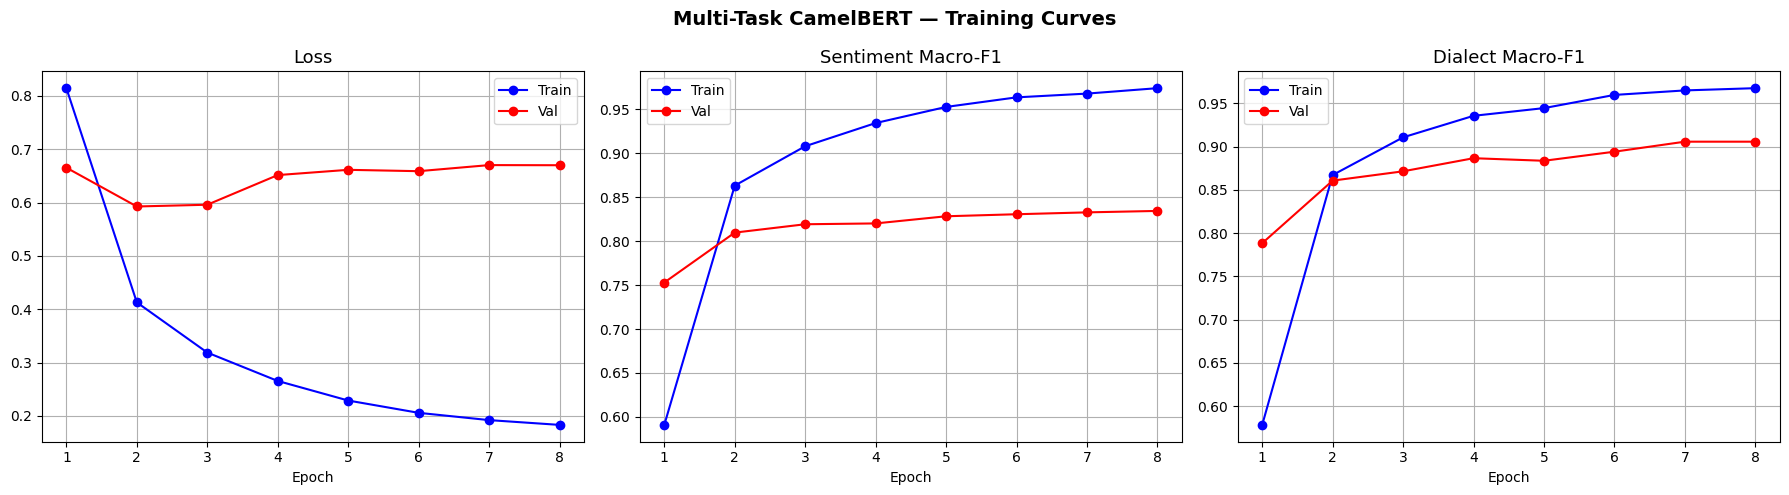

In [ ]:

hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (tr, vl, title) in zip(axes, [
    ('tr_loss','vl_loss','Loss'),
    ('tr_s_f1','vl_s_f1','Sentiment Macro-F1'),
    ('tr_d_f1','vl_d_f1','Dialect Macro-F1')]):
    ax.plot(hist_df['epoch'], hist_df[tr], 'b-o', label='Train')
    ax.plot(hist_df['epoch'], hist_df[vl], 'r-o', label='Val')
    ax.set_title(title, fontsize=13); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True)
plt.suptitle('Multi-Task CamelBERT — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [ ]:

ckpt = torch.load(SAVE_PATH, map_location=device)
model_ft.load_state_dict(ckpt['model_state_dict'])
_, test_sm, test_dm, sent_true, sent_pred, dial_true, dial_pred = evaluate(model_ft, test_loader)
test_s = test_sm['acc']
test_d = test_dm['acc']

print('='*60)
print('  MULTI-TASK CamelBERT — TEST RESULTS')
print('='*60)
print(f"Sentiment Accuracy : {test_sm['acc']:.4f}")
print(f"Sentiment Macro-F1 : {test_sm['macro_f1']:.4f}")
print(f"Dialect   Accuracy : {test_dm['acc']:.4f}")
print(f"Dialect   Macro-F1 : {test_dm['macro_f1']:.4f}")
print('\n── Sentiment Report ──')
print(classification_report(sent_true, sent_pred, target_names=le_sent.classes_))
print('\n── Dialect Report ──')
print(classification_report(dial_true, dial_pred, target_names=le_dial.classes_))


/tmp/ipykernel_1762/2502703542.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(SAVE_PATH, map_location=device)


  MULTI-TASK CamelBERT — TEST RESULTS
Sentiment Accuracy : 0.8364
Sentiment Macro-F1 : 0.8352
Dialect   Accuracy : 0.9142
Dialect   Macro-F1 : 0.9108

── Sentiment Report ──
              precision    recall  f1-score   support

      إيجابي       0.84      0.84      0.84      2511
        سلبي       0.81      0.85      0.83      1371
       محايد       0.85      0.82      0.84      2237

    accuracy                           0.84      6119
   macro avg       0.83      0.84      0.84      6119
weighted avg       0.84      0.84      0.84      6119


── Dialect Report ──
              precision    recall  f1-score   support

    Egyptian       0.96      0.95      0.95      1999
   Jordanian       0.84      0.89      0.87      1523
       Saudi       0.93      0.90      0.91      2597

    accuracy                           0.91      6119
   macro avg       0.91      0.91      0.91      6119
weighted avg       0.92      0.91      0.91      6119



In [ ]:
import pickle, torch

SAVE_DIR = '/content/drive/MyDrive/sentiment_data/'

torch.save(model_ft.state_dict(), SAVE_DIR + 'camelbert_ft.pt')

with open(SAVE_DIR + 'camelbert_le_sent.pkl', 'wb') as f:
    pickle.dump(le_sent, f)

with open(SAVE_DIR + 'camelbert_le_dial.pkl', 'wb') as f:
    pickle.dump(le_dial, f)

print('✅ تم الحفظ في:', SAVE_DIR)
print('الملفات المحفوظة:')
print('  - camelbert_ft.pt')
print('  - camelbert_le_sent.pkl')
print('  - camelbert_le_dial.pkl')

✅ تم الحفظ في: /content/drive/MyDrive/sentiment_data/
الملفات المحفوظة:
  - camelbert_ft.pt
  - camelbert_le_sent.pkl
  - camelbert_le_dial.pkl


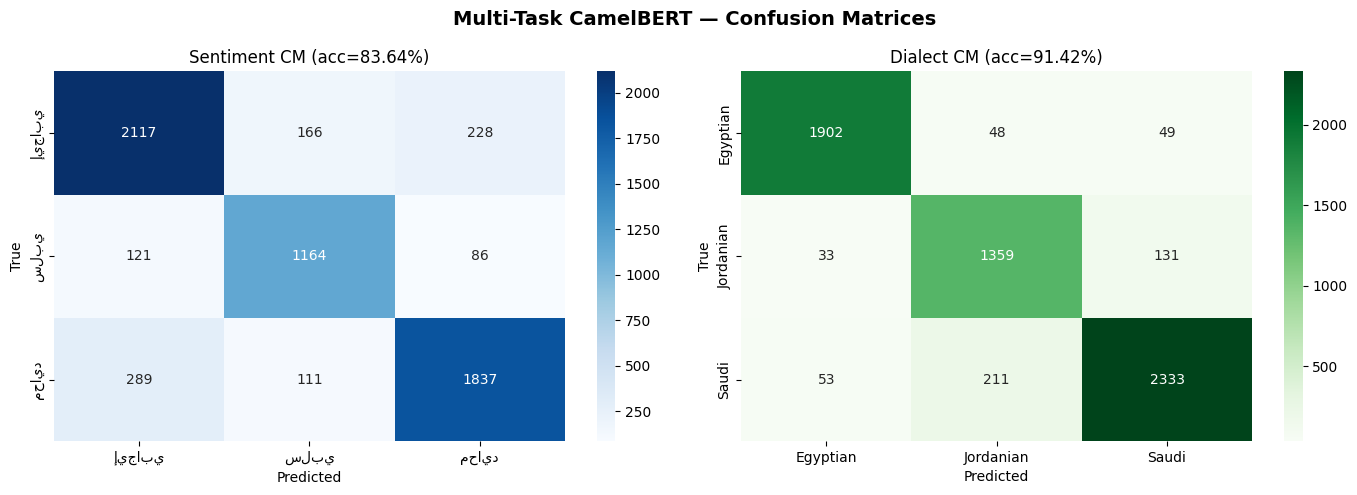

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_s = confusion_matrix(sent_true, sent_pred)
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le_sent.classes_, yticklabels=le_sent.classes_)
axes[0].set_title(f'Sentiment CM (acc={test_s:.2%})')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_d = confusion_matrix(dial_true, dial_pred)
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=le_dial.classes_, yticklabels=le_dial.classes_)
axes[1].set_title(f'Dialect CM (acc={test_d:.2%})')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('Multi-Task CamelBERT — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:

test_dialects = test_df['dialect'].values
print('الدقة و Macro-F1 حسب اللهجة:')
print('='*55)
emoji_map = {'Egyptian':'🇪🇬', 'Jordanian':'🇯🇴', 'Saudi':'🇸🇦', 'Lebanese':'🇱🇧'}
for dialect in list(le_dial.classes_):
    mask   = test_dialects == dialect
    st_d   = np.array(sent_true)[mask]
    sp_d   = np.array(sent_pred)[mask]
    acc    = accuracy_score(st_d, sp_d)
    mf1    = f1_score(st_d, sp_d, average='macro')
    emoji  = emoji_map.get(dialect,'')
    print(f'{emoji} {dialect:12} | Acc: {acc:.4f} | Macro-F1: {mf1:.4f} | n={mask.sum():,}')

# أمثلة الأخطاء تساعدك تعرف هل المشكلة من الداتا أو من الموديل
err = test_df.copy().reset_index(drop=True)
err['true_sentiment'] = le_sent.inverse_transform(sent_true)
err['pred_sentiment'] = le_sent.inverse_transform(sent_pred)
err['true_dialect'] = le_dial.inverse_transform(dial_true)
err['pred_dialect'] = le_dial.inverse_transform(dial_pred)
wrong = err[err['true_sentiment'] != err['pred_sentiment']][['text','dialect','true_sentiment','pred_sentiment','true_dialect','pred_dialect']]
print('\nأول 20 خطأ في المشاعر:')
display(wrong.head(20))


الدقة و Macro-F1 حسب اللهجة:
🇪🇬 Egyptian     | Acc: 0.8584 | Macro-F1: 0.7628 | n=1,999
🇯🇴 Jordanian    | Acc: 0.7853 | Macro-F1: 0.7618 | n=1,523
🇸🇦 Saudi        | Acc: 0.8494 | Macro-F1: 0.8302 | n=2,597

أول 20 خطأ في المشاعر:


,text,dialect,true_sentiment,pred_sentiment,true_dialect,pred_dialect
15,هل يوجد خط من الزمالك لمدينة نصر والعكس,Egyptian,سلبي,إيجابي,Egyptian,Egyptian
30,ياعمي عادي مش فارقه معايا هو انا ههاسب ولا ربنا,Jordanian,محايد,سلبي,Jordanian,Egyptian
31,ما توقعت حدا يحكي عن مدينتي لانه اغلب التركيز ...,Jordanian,محايد,إيجابي,Jordanian,Jordanian
45,سيئ جدا ولا يوجد أى تقدير للعميل ودى اخر مره ا...,Egyptian,إيجابي,سلبي,Egyptian,Egyptian
46,يمشي عادى يالطيف ومنو لمعاه,Jordanian,محايد,إيجابي,Jordanian,Saudi
56,عمر جرب تكون مهندس مدير مشروع بناء كبير ضروري ...,Jordanian,محايد,سلبي,Jordanian,Jordanian
62,كان عندي بعد نظر يوم وقفت مشاهده المسلسل.\nولا...,Saudi,محايد,إيجابي,Saudi,Saudi
76,اني اموت من البصل خاصة المطبوخ اذا بس اشوفة ار...,Saudi,محايد,سلبي,Saudi,Saudi
88,حد يأخذ الدب ذا😓,Saudi,محايد,إيجابي,Saudi,Saudi
95,يارب اجيب 100 ف التحصيلي دعواااتكم ❤\n رجعوني ...,Saudi,محايد,إيجابي,Saudi,Saudi


In [ ]:

print('='*75)
print('         FINAL COMPARISON')
print('='*75)
print(f"{'Model':<35} {'Sent Acc':>10} {'Sent F1':>10} {'Dial Acc':>10} {'Dial F1':>10}")
print('-'*75)
print(f"{'TF-IDF + LR':<35} {acc_tfidf_lr:>10.4f} {'N/A':>10} {'N/A':>10} {'N/A':>10}")
print(f"{'TF-IDF + SVM':<35} {acc_tfidf_svm:>10.4f} {'N/A':>10} {'N/A':>10} {'N/A':>10}")
print(f"{'Word2Vec + SVM':<35} {acc_w2v_svm:>10.4f} {'N/A':>10} {'N/A':>10} {'N/A':>10}")
print(f"{'camelBERT + SVM':<35} {acc_bert_svm:>10.4f} {'N/A':>10} {'N/A':>10} {'N/A':>10}")  # ✅
print(f"{'Multi-Task CamelBERT Fine-Tuned':<35} {test_sm['acc']:>10.4f} {test_sm['macro_f1']:>10.4f} {test_dm['acc']:>10.4f} {test_dm['macro_f1']:>10.4f}")
print('='*75)

         FINAL COMPARISON
Model                                 Sent Acc    Sent F1   Dial Acc    Dial F1
---------------------------------------------------------------------------
TF-IDF + LR                             0.7722        N/A        N/A        N/A
TF-IDF + SVM                            0.7725        N/A        N/A        N/A
Word2Vec + SVM                          0.6892        N/A        N/A        N/A
camelBERT + SVM                         0.7238        N/A        N/A        N/A
Multi-Task CamelBERT Fine-Tuned         0.8364     0.8352     0.9142     0.9108


In [ ]:
import pickle, torch
from transformers import AutoModel

SAVE_DIR = '/content/drive/MyDrive/sentiment_data/'

# تحميل الـ encoders
with open(SAVE_DIR + 'camelbert_le_sent.pkl', 'rb') as f:
    le_sent = pickle.load(f)

with open(SAVE_DIR + 'camelbert_le_dial.pkl', 'rb') as f:
    le_dial = pickle.load(f)

NUM_SENT = len(le_sent.classes_)
NUM_DIAL = len(le_dial.classes_)

# تحميل BERT base ثم بناء المودل بنفس البنية
bert_base = AutoModel.from_pretrained('CAMeL-Lab/bert-base-arabic-camelbert-mix')

model_ft = MultiTaskCamelBERT(
    bert_model=bert_base,
    num_sent=NUM_SENT,
    num_dial=NUM_DIAL,
    dropout=0.25
).to(device)

model_ft.load_state_dict(torch.load(SAVE_DIR + 'camelbert_ft.pt', map_location=device))
model_ft.eval()

print('✅ تم تحميل المودل بنجاح!')
print('المشاعر:', le_sent.classes_)
print('اللهجات:', le_dial.classes_)

/tmp/ipykernel_1762/2495889993.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ft.load_state_dict(torch.load(SAVE_DIR + 'camelbert_ft.pt', map_location=device))


✅ تم تحميل المودل بنجاح!
المشاعر: ['إيجابي' 'سلبي' 'محايد']
اللهجات: ['Egyptian' 'Jordanian' 'Saudi']


## 🎨 واجهة Gradio التفاعلية

In [ ]:
import re
import gradio as gr

SENT_AR = {'إيجابي':'إيجابي 😊', 'سلبي':'سلبي 😞', 'محايد':'محايد 😐'}
DIAL_AR = {'Egyptian':'مصري EG', 'Jordanian':'أردني JO', 'Saudi':'سعودي SA', 'Lebanese':'لبناني LB'}

def _tokens(text):
    return set(str(text).split())

def _has_phrase(text, phrases):
    t = str(text)
    return any(p in t for p in phrases)

# ====== كلمات لهجية قوية ======
EG_STRONG = {
    'النهارده','دلوقتي','دلوقت','اوي','أوي','عايز','عاوز','ازاي',
    'ايه','إيه','كده','كدا','بجد','خالص','فين','منين','امتي',
    'ليه','بتاع','وحش','زفت','زهقان','جامد','جامده'
}

JO_STRONG = {
    'مبارح','امبارح','هاد','هاي','هدول','شو','هسا','هلا','هلأ',
    'عنجد','كتير','بدي','منيح','زاكي','زلمه','زلمة','ولك',
    'ستو','منسف','بلاها','بلاش','يسعدك','يسعدلي','يخوي','يخويي'
}

SA_STRONG = {
    'وع','وش','ابي','أبي','ابغي','أبغى','يبي','ياخي','مره','مرة',
    'الحين','تو','توني','توه','موب','وشذا','وش ذا','وش هال',
    'قهر','تكفى','بالله'
}

SA_CONTEXT = {
    'اليوم','مستانس','ونس','مروق','روق','معصب','عصب',
    'طفشان','طفش','خايس','ضغطي','ضغط'
}

# ====== كلمات مشاعر ======
NEG_ROOTS = {
    'زعل','حزن','تعب','مخنوق','ضايق','تضايق','عصب','ضغط',
    'وجع','الم','ألم','سيئ','وحش','خايس','بشع','ضعيف','فشل',
    'خسر','كسر','خيبه','خيبة','مصيبه','مصيبة','كارثه','كارثة',
    'زفت','قهر','طفش','عيط','صيح','بكي'
}

POS_ROOTS = {
    'عجب','عجبني','حب','ممتاز','روعه','روعة','رائع','تجنن',
    'سعيد','فرح','بسط','ونس','روق','لذيذ','احسن','أحسن',
    'نجح','وفق','ابدع','أبدع','شكر','حلو','جميل','تمام','زين',
    'جامد','جامده'
}

STRONG_NEG_PHRASES = {
    'ما عجبني', 'ما عجبني ولا شي', 'ما عجبني ولا',
    'مو زين', 'مو كويس', 'وع', 'خايس',
    'مرتفع ضغطي', 'ضغطي مرتفع',
}

NEG_PHRASES = {
    'مرتفع ضغطي','ضغطي مرتفع','ما عجبني','مو زين',
    'زعلان','مو كويس','وع','خايس','معصب','معصبه','معصبة'
}

POS_PHRASES = {
    'مروق','مستانس','مستانسه','مستانسة',
    'مبسوطة','مبسوطه','مبسوط',
    'سعيد','جامد','جامده'
}

# ✅ كلمات النفي الصريح
NEGATION_WORDS = {'ما', 'مو', 'مش', 'مب', 'لا', 'مافي', 'مفيش', 'ليس', 'لم', 'لن'}

NEGATABLE_POS = {
    'حبيت', 'حب', 'احب', 'أحب', 'عجبني', 'عجبك', 'عجبه',
    'اعجبني', 'أعجبني', 'نجح', 'وفق', 'ابدع', 'أبدع',
    'جاء', 'زين', 'كويس', 'حلو', 'جميل', 'تمام',
}

def check_negated_positive(text):
    words = str(text).split()
    for i, w in enumerate(words):
        if w in NEGATION_WORDS and i + 1 < len(words):
            next_word = words[i+1]
            # مطابقة كاملة
            if next_word in NEGATABLE_POS:
                return True
            # ✅ مطابقة جزئية — الكلمة تبدأ بجذر إيجابي
            for root in NEGATABLE_POS:
                if next_word.startswith(root):
                    return True
    return False

def apply_sentiment_logic(text, cleaned, sent_label, sp):
    full = str(text) + ' ' + str(cleaned)
    toks = _tokens(cleaned)

    neg_idx = list(le_sent.classes_).index('سلبي')
    pos_idx = list(le_sent.classes_).index('إيجابي')

    # ✅ نفي صريح لكلمة إيجابية
    if check_negated_positive(cleaned):
        return 'سلبي', '100% (مُصحَّح — نفي كلمة إيجابية)'

    # ✅ عبارات سلبية قوية بدون شرط ثقة
    if _has_phrase(full, STRONG_NEG_PHRASES):
        return 'سلبي', '100% (مُصحَّح — نفي قوي)'

    if (toks & NEG_ROOTS) or _has_phrase(full, NEG_PHRASES):
        if sp[pos_idx] < 0.75:
            return 'سلبي', '100% (مُصحَّح بالكلمات)'

    if (toks & POS_ROOTS) or _has_phrase(full, POS_PHRASES):
        if sp[neg_idx] < 0.75:
            return 'إيجابي', '100% (مُصحَّح بالكلمات)'

    return sent_label, f'{sp.max():.1%}'

def apply_dialect_logic(text, cleaned, model_label, model_conf):
    raw = normalize_arabic_light(str(text))
    toks = _tokens(cleaned) | _tokens(raw)

    eg_score = len(toks & EG_STRONG)
    jo_score = len(toks & JO_STRONG)
    sa_score = len(toks & SA_STRONG)

    if _has_phrase(raw, {'وش ذا','وش هال','ياخي','تكفى','بالله'}):
        sa_score += 2

    if 'اليوم' in toks and (toks & SA_CONTEXT):
        sa_score += 1

    # أولوية واضحة للكلمات السعودية
    if sa_score > 0 and sa_score >= eg_score and sa_score >= jo_score:
        return 'سعودي SA', '100% (كلمات سعودية قوية)'

    # جامد/جامده مصري + إيجابي
    if eg_score > 0 and eg_score >= jo_score and eg_score >= sa_score:
        return 'مصري EG', '100% (كلمات مصرية قوية)'

    if jo_score > 0 and jo_score >= eg_score and jo_score >= sa_score:
        return 'أردني JO', '100% (كلمات أردنية قوية)'

    # عيط مشتركة: لا نحسمها إلا لو فيه كلمة لهجية ثانية
    if 'عيط' in toks:
        return DIAL_AR.get(model_label, model_label), f'{model_conf:.1%}'

    # الكلام العام بدون مؤشرات لهجية
    if eg_score == 0 and jo_score == 0 and sa_score == 0:
        return 'مشترك 🌍', '— (لا توجد كلمات لهجية واضحة)'

    if model_conf < 0.55:
        return 'مشترك 🌍', f'{model_conf:.1%} (ثقة منخفضة)'

    return DIAL_AR.get(model_label, model_label), f'{model_conf:.1%}'

def analyze(text):
    if not str(text).strip():
        return '—', '—', '—', '—', '—'

    model_ft.eval()
    cleaned = bert_preprocess(text)

    enc = tokenizer_ft(
        cleaned,
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

    with torch.no_grad():
        s_log, d_log = model_ft(
            enc['input_ids'].to(device),
            enc['attention_mask'].to(device)
        )

    sp = torch.softmax(s_log, dim=1).cpu().numpy()[0]
    dp = torch.softmax(d_log, dim=1).cpu().numpy()[0]

    raw_sent_label = le_sent.classes_[sp.argmax()]
    dial_label = le_dial.classes_[dp.argmax()]

    sent_label, sent_conf = apply_sentiment_logic(text, cleaned, raw_sent_label, sp)
    dial_display, dial_conf = apply_dialect_logic(text, cleaned, dial_label, float(dp.max()))

    sent_breakdown = ' | '.join([
        f'{le_sent.classes_[i]}: {sp[i]:.1%}' for i in range(len(sp))
    ])
    sent_breakdown += f' | النص بعد التطبيع: {cleaned}'

    return sent_label, sent_conf, dial_display, dial_conf, sent_breakdown

examples = [
    ['جامد جدا'],
    ['جامده اوي'],
    ['منسف يخوي'],
    ['بلاها هلا'],
    ['وع الاكل خايس'],
    ['اليوم انا مرتفع ضغطي ومعصب'],
    ['اليوم انت مروق ومستانس'],
    ['مبسوطة مرة'],
    ['تعبان جدا من كل شي'],
    ['اعيط النهارده'],
    ['اعيط'],
    ['عيطت كتير مبارح'],
    ['ابي حل ياخي'],
    ['وش ذا التطبيق'],
    ['عايز أكل كويس النهارده'],
    ['التطبيق وحش جداً ومش بيشتغل'],
    ['ما حبيت الفيلم'],
    ['مو عجبني'],
    ['ما اعجبني ولا شي'],
]

with gr.Blocks(title='Arabic Dialect Sentiment Analysis — CamelBERT', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🔍 محلل مشاعر اللهجات العربية
    ## أردني JO | مصري EG | سعودي SA
    *مبني على CamelBERT Multi-Task Fine-Tuning + Root/Gender Normalization*
    """)

    with gr.Row():
        with gr.Column(scale=2):
            text_in = gr.Textbox(label='النص', placeholder='اكتب النص هنا...', lines=3)
            btn = gr.Button('🔍 تحليل', variant='primary')
            gr.Examples(examples=examples, inputs=text_in)

        with gr.Column(scale=1):
            sent_out = gr.Textbox(label='المشاعر')
            sent_conf_out = gr.Textbox(label='الثقة في المشاعر')
            dial_out = gr.Textbox(label='اللهجة')
            dial_conf_out = gr.Textbox(label='الثقة في اللهجة')
            breakdown_out = gr.Textbox(label='توزيع احتمالات المشاعر + التطبيع')

    btn.click(
        fn=analyze,
        inputs=text_in,
        outputs=[sent_out, sent_conf_out, dial_out, dial_conf_out, breakdown_out]
    )

    text_in.submit(
        fn=analyze,
        inputs=text_in,
        outputs=[sent_out, sent_conf_out, dial_out, dial_conf_out, breakdown_out]
    )

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Running on public URL: https://59808587dcfb50c208.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://59808587dcfb50c208.gradio.live


In [ ]:
demo.launch(share=True, debug=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Running on public URL: https://59808587dcfb50c208.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


KeyboardInterrupt: 